In [25]:
from sqlalchemy import create_engine
import urllib

connection_string = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-5RVJNFO;"      # or localhost
    "DATABASE=ecommerce;"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={connection_string}"
)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
import urllib

Matplotlib is building the font cache; this may take a moment.


In [29]:
query = """
SELECT

o.order_id,

o.customer_id,

o.order_purchase_timestamp,

o.order_delivered_customer_date,

c.customer_state,

oi.product_id,

oi.price,

oi.freight_value,

p.product_category_name,

op.payment_type,

op.payment_value

FROM orders o

JOIN customers c
ON o.customer_id=c.customer_id

JOIN order_items oi
ON o.order_id=oi.order_id

JOIN products p
ON oi.product_id=p.product_id

JOIN order_payments op
ON o.order_id=op.order_id
"""

df = pd.read_sql(query, engine)

In [30]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,customer_state,product_id,price,freight_value,product_category_name,payment_type,payment_value
0,02564f320004c61ebf621191f06365a9,29880b59222c463f415962d277f449df,2018-02-18 17:02:17,2018-03-02 17:03:55,SP,2e0ce433616916840a405d0853407af8,25.9,11.85,informatica_acessorios,credit_card,37.75
1,03a3628434dd670dd5b9896337451c86,e4c8227df878d2e203bc81fc1351342f,2017-07-20 19:26:06,2017-08-01 16:46:56,MG,548ace38f22cc53db6f049c551d31397,179.9,17.02,ferramentas_jardim,credit_card,393.84
2,03a3628434dd670dd5b9896337451c86,e4c8227df878d2e203bc81fc1351342f,2017-07-20 19:26:06,2017-08-01 16:46:56,MG,548ace38f22cc53db6f049c551d31397,179.9,17.02,ferramentas_jardim,credit_card,393.84
3,041fd411ba3cebfe101d1dadc0666ce6,f9744f196723a6eaf6810ba6b7432532,2018-02-12 21:47:28,2018-03-05 14:13:42,RS,629e019a6f298a83aeecc7877964f935,119.9,25.68,automotivo,credit_card,145.58
4,083c3a567b005b0f7261c9c0c76fe151,d4a6786c02a6e6ba536f58e3b4a13393,2017-02-12 15:45:27,2017-03-03 19:25:33,MG,7868a64aa111bbb4f41f8e1146c0becb,59.9,17.16,moveis_decoracao,credit_card,77.06


In [31]:
#Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117601 non-null  str           
 1   customer_id                    117601 non-null  str           
 2   order_purchase_timestamp       117601 non-null  datetime64[us]
 3   order_delivered_customer_date  115034 non-null  datetime64[us]
 4   customer_state                 117601 non-null  str           
 5   product_id                     117601 non-null  str           
 6   price                          117601 non-null  float64       
 7   freight_value                  117601 non-null  float64       
 8   product_category_name          115903 non-null  str           
 9   payment_type                   117601 non-null  str           
 10  payment_value                  117601 non-null  float64       
dtypes: datetime

In [32]:
df.describe()

,order_purchase_timestamp,order_delivered_customer_date,price,freight_value,payment_value
count,117601,115034,117601.000000,117601.000000,117601.000000
mean,2017-12-30 16:19:35.878368,2018-01-13 06:45:43.565711,120.824783,20.088376,172.686752
min,2016-09-04 21:15:19,2016-10-11 13:46:32,0.850000,0.000000,0.000000
25%,2017-09-11 21:42:39,2017-09-25 14:09:30.250000,39.900000,13.080000,60.870000
50%,2018-01-18 13:37:27,2018-02-01 19:17:46,74.900000,16.310000,108.210000
75%,2018-05-03 22:43:17,2018-05-15 16:52:09.250000,134.900000,21.200000,189.260000
max,2018-09-03 09:06:57,2018-10-17 13:22:46,6735.000000,409.680000,13664.080000
std,NaN,NaN,184.479323,16.082675,267.592290


In [33]:
df.shape

(117601, 11)

In [36]:
#Check Missing Values
df.isnull().sum()

order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_delivered_customer_date    2567
customer_state                      0
product_id                          0
price                               0
freight_value                       0
product_category_name            1698
payment_type                        0
payment_value                       0
dtype: int64

In [37]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(11215)

In [38]:
df = df.drop_duplicates()

In [43]:
#Revenue by Month
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp']) #Convert the purchase timestamp

df['Month'] = df['order_purchase_timestamp'].dt.to_period('M') #Create a month column

#Calculate monthly revenue
monthly_sales = (
    df.groupby('Month')['payment_value']
      .sum()
)

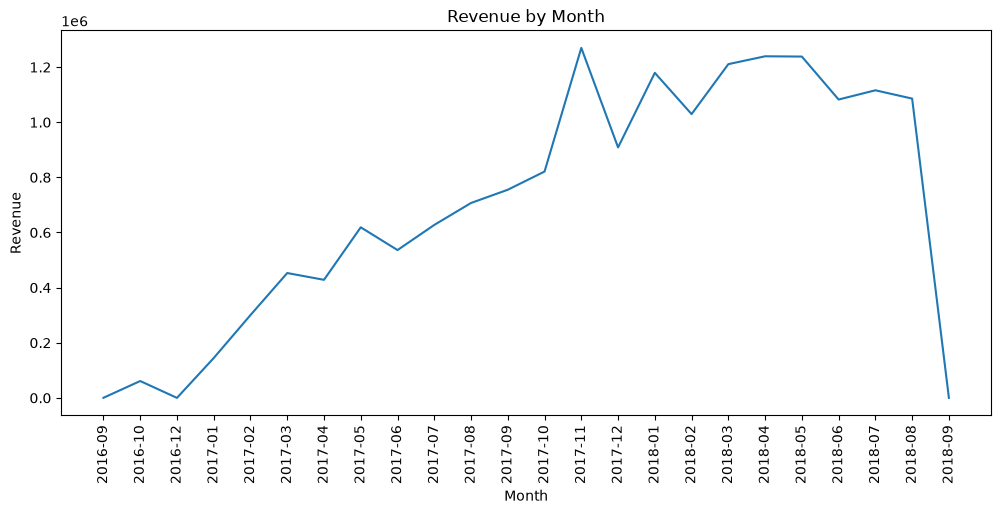

In [42]:
#Plot revenue by month
plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values)

plt.xticks(rotation=90)

plt.title("Revenue by Month")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

In [45]:
#Top Product Categories
top_categories = (
    df.groupby("product_category_name")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_categories

product_category_name
beleza_saude              1492735.28
cama_mesa_banho           1453936.81
relogios_presentes        1350265.29
esporte_lazer             1202367.42
informatica_acessorios    1146724.92
moveis_decoracao          1021687.60
utilidades_domesticas      822901.25
cool_stuff                 735284.82
automotivo                 716884.03
ferramentas_jardim         620872.32
Name: payment_value, dtype: float64

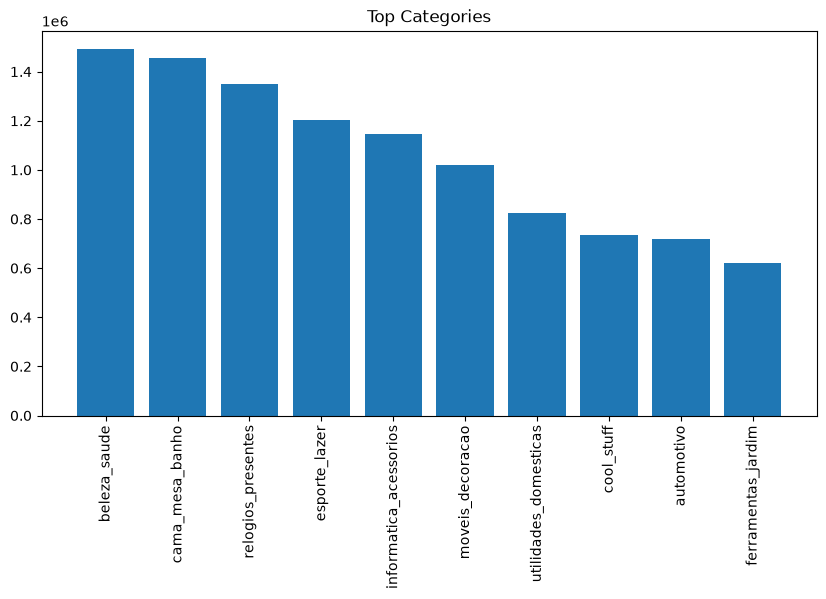

In [47]:
#Plot top categories
plt.figure(figsize=(10,5))

plt.bar(top_categories.index,
        top_categories.values)

plt.xticks(rotation=90)

plt.title("Top Categories")

plt.show()

In [51]:
#Top states
top_states = (
    df.groupby("customer_state")["payment_value"]
      .sum()
      .sort_values(ascending=False)
)
top_states.head(5)

customer_state
SP    6311038.97
RJ    2255342.41
MG    1965483.77
RS     936030.28
PR     848529.15
Name: payment_value, dtype: float64

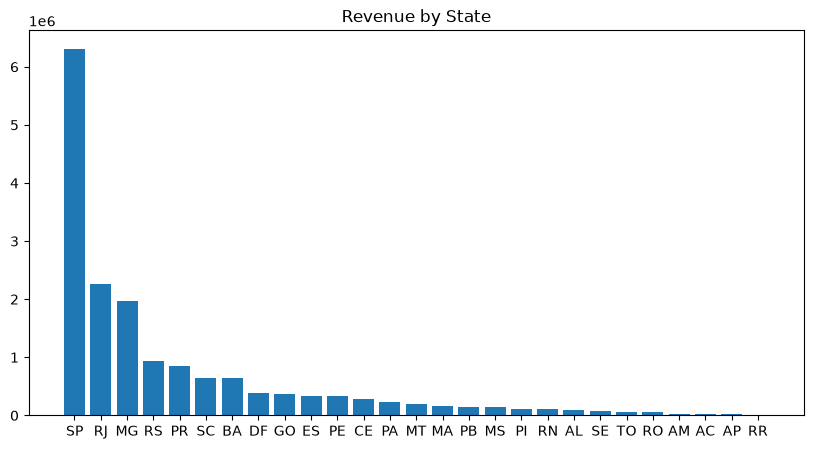

In [54]:
#Plot top states
plt.figure(figsize=(10,5))

plt.bar(top_states.index,
        top_states.values)

plt.title("Revenue by State")

plt.show()

In [55]:
#Most Valuable Customers
top_customers = (
    df.groupby("customer_id")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

customer_id
71901689c5f3e5adc27b1dd16b33f0b8    15978.65
1617b1357756262bfa56ab541c47bc16    13664.08
0d861a5e4dd6a9079d89e1330848f0ab     9258.24
cc803a2c412833101651d3f90ca7de24     8891.00
30bb84b541c96af98ba7d90b9ebf35d0     8697.99
5e312b0d9bf5c91599eb42120e633b19     8530.14
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
Name: payment_value, dtype: float64

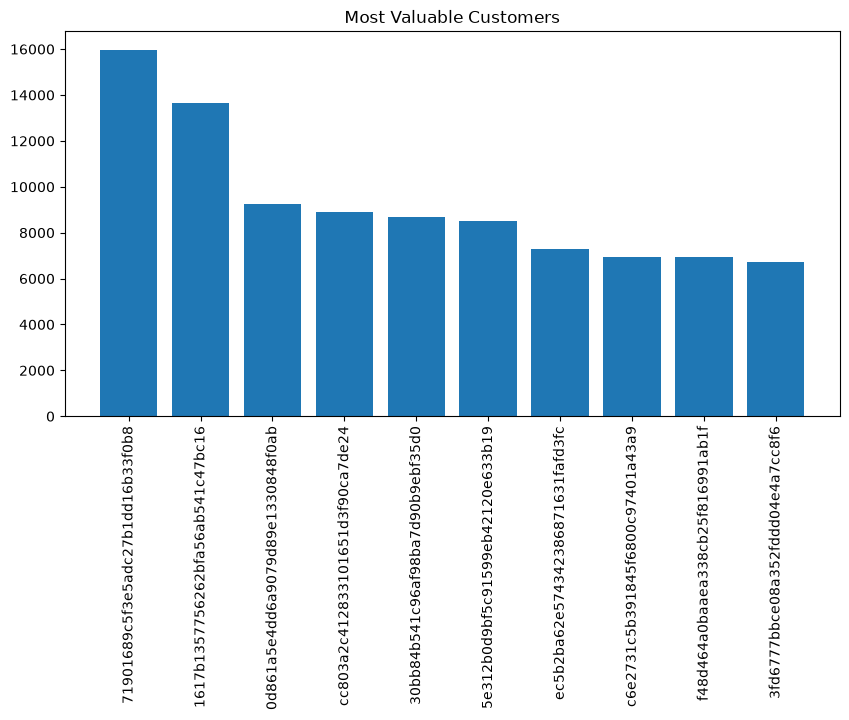

In [57]:
plt.figure(figsize=(10,5))

plt.bar(top_customers.index,
        top_customers.values)

plt.xticks(rotation=90)

plt.title("Most Valuable Customers")

plt.show()

In [58]:
#Payment Types
payment = df['payment_type'].value_counts()

payment

payment_type
credit_card    79258
boleto         20288
voucher         5256
debit_card      1584
Name: count, dtype: int64

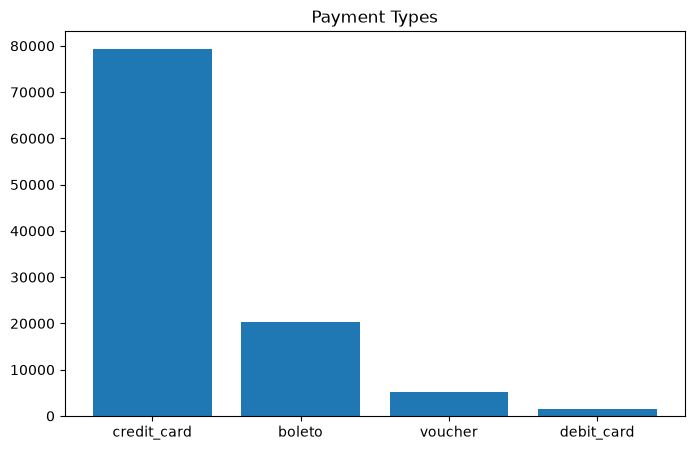

In [59]:
#Plot payment types
plt.figure(figsize=(8,5))

plt.bar(payment.index,
        payment.values)

plt.title("Payment Types")

plt.show()

In [60]:
#Delivery Time
df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date']
)

df['DeliveryDays'] = (
    df['order_delivered_customer_date']
    -
    df['order_purchase_timestamp']
).dt.days

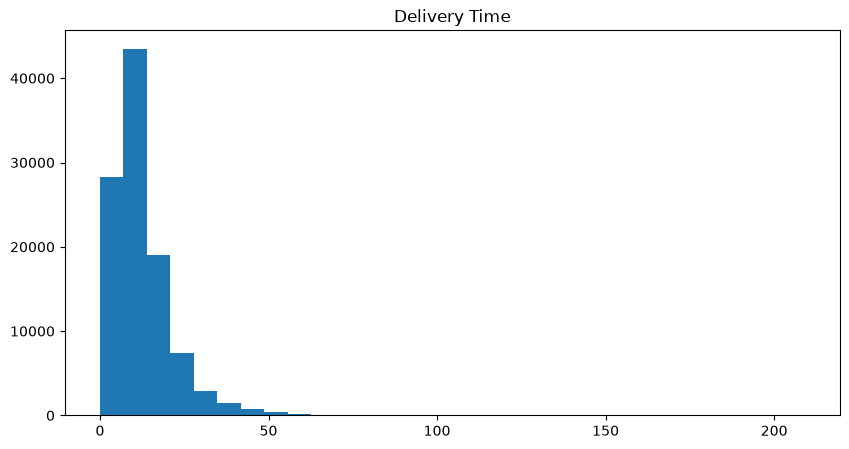

In [61]:
#Plot delivery time
plt.figure(figsize=(10,5))

plt.hist(df['DeliveryDays'],
         bins=30)

plt.title("Delivery Time")

plt.show()

In [64]:
#Outlier Detection
Q1 = df['payment_value'].quantile(0.25)

Q3 = df['payment_value'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['payment_value'] < Q1 - 1.5 * IQR)
    |
    (df['payment_value'] > Q3 + 1.5 * IQR)
]

len(outliers)

8187

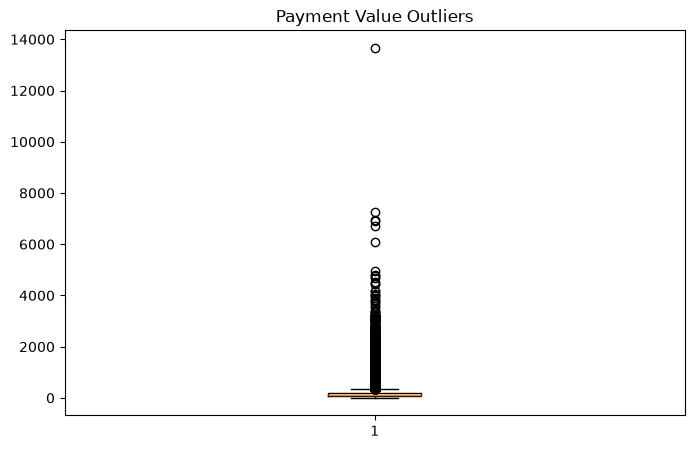

In [65]:
#Plot outliers
plt.figure(figsize=(8,5))

plt.boxplot(df['payment_value'])

plt.title("Payment Value Outliers")

plt.show()